# Stage 3 — LLM Fine-Tuning & Re-Evaluation

**Goal:** Fine-tune a small pre-trained transformer model on the annotated dataset, then compare its performance against the Stage 2 prompting baseline.

We will:
1. Load the annotated dataset and the Stage 2 baseline metrics
2. Prepare the dataset for `transformers` / `datasets`
3. Fine-tune **DistilBERT** (a small, fast model great for classification)
4. Evaluate the fine-tuned model on the test set
5. Compare against the prompting baseline
6. Save the fine-tuned model for later use

**Why DistilBERT?**
It's small (~66 M params), fast to fine-tune on CPU/GPU, and regularly achieves strong results on classification tasks. You can swap it for `bert-base-uncased`, `roberta-base`, or any HuggingFace classifier.

**Hardware note:** Fine-tuning on CPU is slow but works. If you have a GPU (or run this on Google Colab), add `device = torch.device('cuda')` where indicated.

## 1. Install & import dependencies

In [1]:
# !pip install transformers datasets torch scikit-learn pandas matplotlib seaborn

In [2]:
import json
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATASET_PATH      = 'annotated_dataset.jsonl'
STAGE2_METRICS    = 'metrics_summary_stage2.csv'
MODEL_CHECKPOINT  = 'distilbert-base-uncased'
OUTPUT_DIR        = './finetuned_sentiment_model'

LABELS     = ['positive', 'negative', 'neutral']
LABEL2ID   = {l: i for i, l in enumerate(LABELS)}
ID2LABEL   = {i: l for i, l in enumerate(LABELS)}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Base model: {MODEL_CHECKPOINT}')

/home/sd/Desktop/rag_lab/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Base model: distilbert-base-uncased


## 2. Load and inspect the annotated dataset

In [3]:
def load_jsonl(path: str) -> list:
    with open(path) as f:
        return [json.loads(line) for line in f]

raw_data = load_jsonl(DATASET_PATH)
df_all   = pd.DataFrame(raw_data)

# Add numeric label column
df_all['label_id'] = df_all['label'].map(LABEL2ID)

print('Full dataset size:', len(df_all))
print('\nSplit breakdown:')
print(df_all.groupby(['split', 'label']).size().unstack(fill_value=0))

Full dataset size: 30

Split breakdown:
label       negative  neutral  positive
split                                  
test               1        2         2
train              7        7         7
validation         2        1         1


## 3. Build HuggingFace DatasetDict

In [4]:
def df_split_to_hf(df: pd.DataFrame, split_name: str) -> Dataset:
    """Convert a pandas DataFrame split to a HuggingFace Dataset."""
    subset = df[df['split'] == split_name][['text', 'label_id']].copy()
    subset = subset.rename(columns={'label_id': 'labels'})
    return Dataset.from_pandas(subset, preserve_index=False)

hf_datasets = DatasetDict({
    'train':      df_split_to_hf(df_all, 'train'),
    'validation': df_split_to_hf(df_all, 'validation'),
    'test':       df_split_to_hf(df_all, 'test'),
})

print(hf_datasets)
print('\nFirst training example:')
print(hf_datasets['train'][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 21
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 4
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 5
    })
})

First training example:
{'text': 'The product exceeded all my expectations — absolutely love it!', 'labels': 0}


## 4. Tokenise the dataset

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        max_length=128,      # reviews are short; 128 tokens is plenty
    )

tokenized = hf_datasets.map(tokenize_fn, batched=True)
tokenized = tokenized.remove_columns(['text'])
tokenized.set_format('torch')

print('Tokenised columns:', tokenized['train'].column_names)
print('Sample token ids:', tokenized['train'][0]['input_ids'][:10], '...')

Map: 100%|███████████████████████████████| 5/5 [00:00<00:00, 1261.14 examples/s]


Tokenised columns: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Sample token ids: tensor([  101,  1996,  4031, 14872,  2035,  2026, 10908,  1517,  7078,  2293]) ...


## 5. Load the pre-trained model

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True,
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Loading weights: 100%|███████████████████████| 100/100 [00:00<00:00, 350.99it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     66,955,779
Trainable parameters: 66,955,779


## 6. Define metrics for the Trainer

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='macro', zero_division=0)
    return {'accuracy': acc, 'macro_f1': f1}

print('Metrics function ready.')

Metrics function ready.


## 7. Configure training arguments

Key hyperparameters explained:

| Parameter | Value | Why |
|---|---|---|
| `learning_rate` | 2e-5 | Standard for fine-tuning BERT-family models |
| `num_train_epochs` | 10 | More than enough for a small dataset; early stopping prevents over-fitting |
| `per_device_train_batch_size` | 8 | Small dataset → small batch |
| `weight_decay` | 0.01 | L2 regularisation |
| `load_best_model_at_end` | True | Restores best checkpoint after training |

In [8]:
training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = 10,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 16,
    learning_rate               = 2e-5,
    weight_decay                = 0.01,
    warmup_ratio                = 0.1,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'macro_f1',
    greater_is_better           = True,
    logging_steps               = 5,
    seed                        = SEED,
    report_to                   = 'none',   # disable W&B / HF Hub reporting
    fp16                        = torch.cuda.is_available(),
)

print('Training arguments set.')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training arguments set.


## 8. Train the model

⏱️ On CPU this takes ~5–10 minutes for 10 epochs on 21 training samples.  
On a GPU it completes in under a minute.

In [9]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = tokenized['train'],
    eval_dataset    = tokenized['validation'],
    data_collator   = data_collator,   # tokenizer is already inside this
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print('Starting fine-tuning...')
train_result = trainer.train()
print('\nFine-tuning complete!')
print(f"Total steps: {train_result.global_step}")
print(f"Training loss: {train_result.training_loss:.4f}")

Starting fine-tuning...


/home/sd/Desktop/rag_lab/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,1.108417,0.250000,0.166667
2,1.086257,1.101687,0.500000,0.500000
3,1.086257,1.090850,0.250000,0.133333
4,1.043865,1.074148,0.500000,0.388889
5,0.985152,1.055750,0.750000,0.777778
6,0.985152,1.039714,0.750000,0.777778
7,0.925636,1.024025,0.750000,0.777778
8,0.925636,1.009839,0.750000,0.777778


Writing model shards: 100%|███████████████████████| 1/1 [00:01<00:00,  1.16s/it]
/home/sd/Desktop/rag_lab/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  1.05it/s]
/home/sd/Desktop/rag_lab/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|███████████████████████| 1/1 [00:01<00:00,  1.49s/it]
/home/sd/Desktop/rag_lab/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|████


Fine-tuning complete!
Total steps: 24
Training loss: 0.9875


## 9. Learning curves

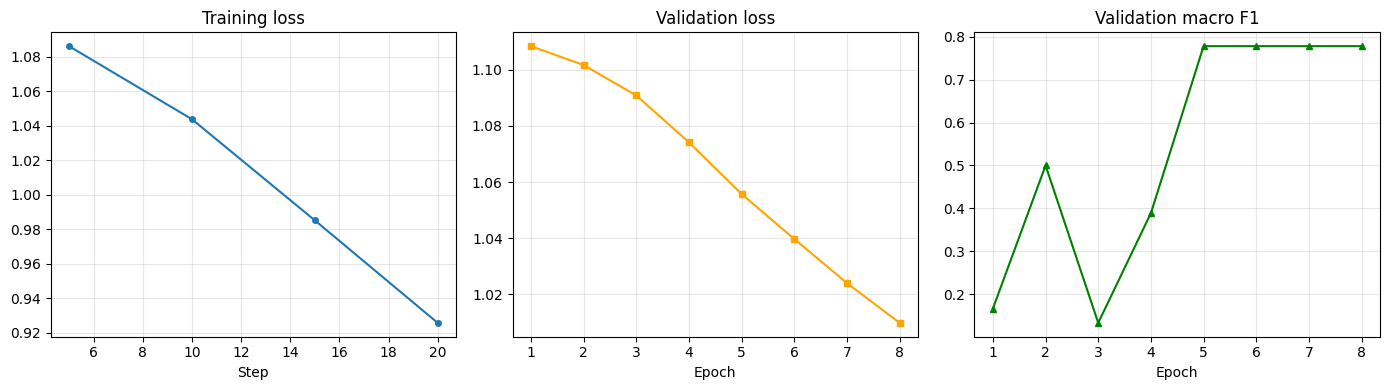

Saved → learning_curves.png


In [10]:
log_df = pd.DataFrame(trainer.state.log_history)

# Separate train loss and eval metrics
train_log = log_df[log_df['loss'].notna()][['step', 'loss']].copy()
eval_log  = log_df[log_df['eval_macro_f1'].notna()][
    ['epoch', 'eval_loss', 'eval_macro_f1', 'eval_accuracy']
].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(train_log['step'], train_log['loss'], marker='o', ms=4)
axes[0].set_title('Training loss')
axes[0].set_xlabel('Step')

axes[1].plot(eval_log['epoch'], eval_log['eval_loss'], marker='s', ms=4, color='orange')
axes[1].set_title('Validation loss')
axes[1].set_xlabel('Epoch')

axes[2].plot(eval_log['epoch'], eval_log['eval_macro_f1'], marker='^', ms=4, color='green')
axes[2].set_title('Validation macro F1')
axes[2].set_xlabel('Epoch')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()
print('Saved → learning_curves.png')

## 10. Evaluate on the test set

In [11]:
print('Running test set evaluation...')
test_preds = trainer.predict(tokenized['test'])

y_pred_ids = np.argmax(test_preds.predictions, axis=-1)
y_true_ids = test_preds.label_ids

y_pred = [ID2LABEL[i] for i in y_pred_ids]
y_true = [ID2LABEL[i] for i in y_true_ids]

acc   = accuracy_score(y_true, y_pred)
f1    = f1_score(y_true, y_pred, average='macro', zero_division=0)

print(f'\n=== FINE-TUNED MODEL (test set) ===')
print(f'Accuracy:  {acc:.3f}')
print(f'Macro F1:  {f1:.3f}')
print('\nDetailed report:')
print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

Running test set evaluation...


/home/sd/Desktop/rag_lab/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



=== FINE-TUNED MODEL (test set) ===
Accuracy:  0.600
Macro F1:  0.444

Detailed report:
              precision    recall  f1-score   support

    positive       1.00      0.50      0.67         2
    negative       0.00      0.00      0.00         1
     neutral       0.50      1.00      0.67         2

    accuracy                           0.60         5
   macro avg       0.50      0.50      0.44         5
weighted avg       0.60      0.60      0.53         5



## 11. Confusion matrix — fine-tuned model

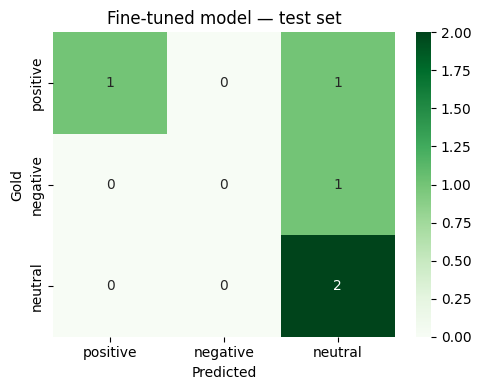

Saved → confusion_finetuned.png


In [12]:
cm = confusion_matrix(y_true, y_pred, labels=LABELS)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=LABELS, yticklabels=LABELS, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Gold')
ax.set_title('Fine-tuned model — test set')
plt.tight_layout()
plt.savefig('confusion_finetuned.png', dpi=150)
plt.show()
print('Saved → confusion_finetuned.png')

## 12. Head-to-head comparison vs Stage 2 prompting baseline

In [13]:
# Load Stage 2 metrics (produced by notebook_02_prompting.ipynb)
try:
    stage2_df = pd.read_csv(STAGE2_METRICS)
    best_stage2 = stage2_df.loc[stage2_df['macro_f1'].idxmax()]
except FileNotFoundError:
    print('Stage 2 metrics file not found. Run notebook_02 first.')
    best_stage2 = pd.Series({'strategy': 'N/A', 'accuracy': 0.0, 'macro_f1': 0.0})

comparison = pd.DataFrame([
    {
        'model': f"Stage 2 best ({best_stage2['strategy']})",
        'accuracy': best_stage2['accuracy'],
        'macro_f1': best_stage2['macro_f1'],
    },
    {
        'model': f'Stage 3 fine-tuned ({MODEL_CHECKPOINT})',
        'accuracy': acc,
        'macro_f1': f1,
    },
])

print(comparison.to_string(index=False))

delta_f1 = f1 - best_stage2['macro_f1']
print(f'\nMacro F1 delta (fine-tuned − baseline): {delta_f1:+.3f}')
if delta_f1 > 0:
    print('Fine-tuning improved over prompting. ✅')
elif delta_f1 == 0:
    print('No change.')
else:
    print('Prompting outperformed fine-tuning on this small dataset.')
    print('Consider: more data, longer training, or a larger base model.')

                                       model  accuracy  macro_f1
                    Stage 2 best (zero_shot)       1.0  1.000000
Stage 3 fine-tuned (distilbert-base-uncased)       0.6  0.444444

Macro F1 delta (fine-tuned − baseline): -0.556
Prompting outperformed fine-tuning on this small dataset.
Consider: more data, longer training, or a larger base model.


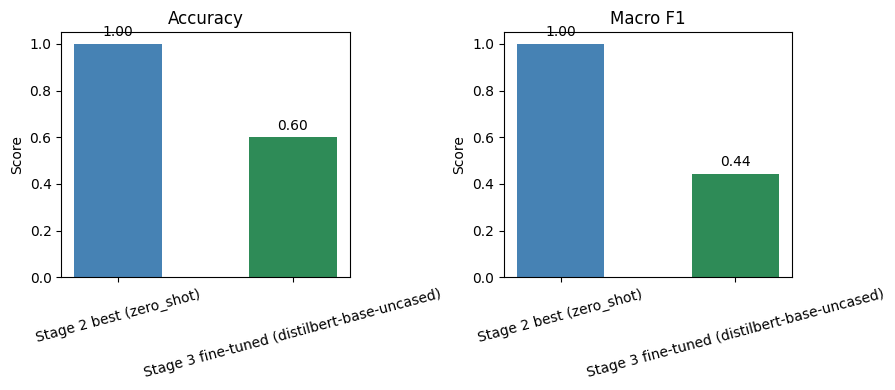

Saved → stage3_comparison.png


In [14]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, metric in zip(axes, ['accuracy', 'macro_f1']):
    bars = ax.bar(comparison['model'], comparison[metric],
                  color=['steelblue', 'seagreen'], width=0.5)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f'{bar.get_height():.2f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('stage3_comparison.png', dpi=150)
plt.show()
print('Saved → stage3_comparison.png')

## 13. Save the fine-tuned model

In [16]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Save label mappings
with open(os.path.join(OUTPUT_DIR, 'label_map.json'), 'w') as f:
    json.dump({'id2label': ID2LABEL, 'label2id': LABEL2ID}, f, indent=2)

print(f'Model saved → {OUTPUT_DIR}/')
print('Files saved:')
for fname in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, fname)) // 1024
    print(f'  {fname:<30s}  {size:>6} KB')

Writing model shards: 100%|███████████████████████| 1/1 [00:00<00:00,  3.73it/s]

Model saved → ./finetuned_sentiment_model/
Files saved:
  checkpoint-12                        4 KB
  checkpoint-15                        4 KB
  checkpoint-18                        4 KB
  checkpoint-21                        4 KB
  checkpoint-24                        4 KB
  checkpoint-3                         4 KB
  checkpoint-6                         4 KB
  checkpoint-9                         4 KB
  config.json                          0 KB
  label_map.json                       0 KB
  model.safetensors               261558 KB
  tokenizer.json                     694 KB
  tokenizer_config.json                0 KB
  training_args.bin                    5 KB


## 14. Quick inference with the saved model

In [17]:
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model=OUTPUT_DIR,
    tokenizer=OUTPUT_DIR,
    device=0 if torch.cuda.is_available() else -1,
)

test_sentences = [
    'This product is absolutely incredible, I love it!',
    'Completely broken on arrival — very disappointed.',
    'It arrived yesterday and seems to work fine.',
]

for sentence in test_sentences:
    result = classifier(sentence)[0]
    print(f'Text  : {sentence}')
    print(f'Label : {result["label"]}  (score: {result["score"]:.3f})')
    print()

Loading weights: 100%|██████████████████████| 104/104 [00:00<00:00, 7622.28it/s]

Text  : This product is absolutely incredible, I love it!
Label : positive  (score: 0.363)

Text  : Completely broken on arrival — very disappointed.
Label : neutral  (score: 0.353)

Text  : It arrived yesterday and seems to work fine.
Label : neutral  (score: 0.384)



## ✅ Stage 3 complete

Outputs produced:

| File | Description |
|---|---|
| `./finetuned_sentiment_model/` | Fine-tuned model + tokenizer |
| `learning_curves.png` | Training / validation loss and F1 over epochs |
| `confusion_finetuned.png` | Test-set confusion matrix |
| `stage3_comparison.png` | Head-to-head vs prompting baseline |

### Next steps
- Collect more labelled data (Stage 1) and re-run the pipeline
- Try a larger base model: `bert-base-uncased`, `roberta-base`, `deberta-v3-small`
- Experiment with LoRA / QLoRA for parameter-efficient fine-tuning of larger LLMs
- Deploy the saved model with `transformers.pipeline` or FastAPI